<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Evaluation, Baselines, and Data Hygiene

_Prepared by Claudia Zendejas-Morales_

A QML model is not evaluated fairly just because it reaches a high accuracy once. A defensible comparison also depends on how the data were split, how preprocessing was fit, which baselines were included, and how uncertainty across runs was reported. In hybrid quantum machine learning, these choices are especially important because small datasets, low-dimensional feature maps, and expensive training loops make it easy to over-interpret weak evidence.

The discussion below develops the evaluation side of a supervised QML workflow. It defines train-validation-test hygiene formally, makes explicit what it means to compare models on the same representation, and studies how simple classical baselines should be used before any stronger claim is made. The main case study uses a small matched-feature classification pipeline on the breast cancer dataset, where logistic regression, SVM, and a variational quantum classifier are evaluated under the same split and the same train-only preprocessing rules.


<p align="center">
  <img align="center" style="display:block; margin-left: auto; margin-right: auto;" src="./images/evaluation-hygiene-pipeline.png" alt="A fair QML evaluation pipeline" width="800"/>
</p>

The image summarizes a standard evaluation logic for supervised ML and QML. The split is created first, every preprocessing map is fit on $D_{\mathrm{train}}$ only, all matched baselines receive the same transformed data, model selection is done on $D_{\mathrm{val}}$, and $D_{\mathrm{test}}$ is reserved for the final report. That order matters because reversing it leaks information across splits and makes the final comparison unreliable.


## From raw data to a fair comparison

Let the labeled dataset be

$$
D = \{(\vec{x}^{\,j}, y^j)\}_{j=1}^{M}
$$

and let it be partitioned into three disjoint subsets

$$
D_{\mathrm{train}},\qquad D_{\mathrm{val}},\qquad D_{\mathrm{test}}
$$

such that

$$
D = D_{\mathrm{train}} \cup D_{\mathrm{val}} \cup D_{\mathrm{test}}
$$

and

$$
D_{\mathrm{train}} \cap D_{\mathrm{val}} = \varnothing,\qquad D_{\mathrm{train}} \cap D_{\mathrm{test}} = \varnothing,\qquad D_{\mathrm{val}} \cap D_{\mathrm{test}} = \varnothing
$$

The intended roles of these subsets are different. The model parameters are fit on $D_{\mathrm{train}}$, hyperparameters and checkpoints are chosen on $D_{\mathrm{val}}$, and the final generalization report is produced on $D_{\mathrm{test}}$. If $D_{\mathrm{test}}$ influences preprocessing, feature selection, checkpoint choice, or hyperparameter tuning, then it no longer acts as unseen data.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Split first, preprocess second</b><br>
Data hygiene starts before any model is trained. The correct order is: create the split, fit preprocessing objects on the training split, transform validation and test without refitting, train the models, select on validation, and evaluate once on test. Any preprocessing object that has seen validation or test data has already broken the protocol.
</div>


## Metrics and what they measure

For binary classification, let the hard predictions and labels be

$$
\hat y^j \in \{0,1\},\qquad y^j \in \{0,1\}
$$

From them one obtains the confusion-matrix counts $\mathrm{TP}$, $\mathrm{FP}$, $\mathrm{TN}$, and $\mathrm{FN}$. Three common metrics are then

$$
\mathrm{Accuracy}=\frac{\mathrm{TP}+\mathrm{TN}}{\mathrm{TP}+\mathrm{TN}+\mathrm{FP}+\mathrm{FN}}
$$

$$
\mathrm{Precision}=\frac{\mathrm{TP}}{\mathrm{TP}+\mathrm{FP}},\qquad \mathrm{Recall}=\frac{\mathrm{TP}}{\mathrm{TP}+\mathrm{FN}}
$$

and

$$
F_1=\frac{2\,(\mathrm{Precision})(\mathrm{Recall})}{\mathrm{Precision}+\mathrm{Recall}}
$$

Accuracy measures overall correctness, while $F_1$ is more sensitive to the balance between false positives and false negatives. In addition, score-based metrics such as ROC-AUC do not use only hard labels; they evaluate how well the model ranks positive samples above negative ones across possible thresholds.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>What do TP, TN, FP, and FN mean?</b><br>
The initials stand for <b>true positive</b> (TP), <b>true negative</b> (TN), <b>false positive</b> (FP), and <b>false negative</b> (FN). A true positive is a sample whose true label is $1$ and that is predicted as $1$. A true negative is a sample whose true label is $0$ and that is predicted as $0$. A false positive is a sample whose true label is $0$ but that is predicted as $1$, while a false negative is a sample whose true label is $1$ but that is predicted as $0$.
</div>


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>No single metric is enough</b><br>
A model can improve accuracy while worsening recall on the minority class, or keep the same accuracy while changing its probability ranking substantially. That is why fair ML and QML evaluations usually report several metrics together and also look at confusion matrices instead of trusting one scalar summary blindly.
</div>


## Fair preprocessing for QML and its baselines

In a matched-feature QML comparison, all models should see the same transformed representation. Suppose a training-only standardization map is fit on $D_{\mathrm{train}}$ and produces per-feature means $\mu_m^{\mathrm{train}}$ and standard deviations $\sigma_m^{\mathrm{train}}$. Then a raw feature vector is standardized as

$$
x_m^{\prime}=\frac{x_m-\mu_m^{\mathrm{train}}}{\sigma_m^{\mathrm{train}}}
$$

If a dimensionality-reduction map such as PCA is also fit on $D_{\mathrm{train}}$, its output can be written abstractly as $\vec{z}^{\,j}=P_{\mathrm{train}}(\vec{x}^{\,j\prime})$, where $P_{\mathrm{train}}$ denotes the PCA map learned from the training split only. For a quantum feature map with angle inputs, one may need one more train-only rescaling step, for example

$$
\tilde x_m^{\,j}=\pi\,\frac{z_m^{\,j}-a_m^{\mathrm{train}}}{b_m^{\mathrm{train}}-a_m^{\mathrm{train}}}
$$

Here $a_m^{\mathrm{train}}$ and $b_m^{\mathrm{train}}$ denote, respectively, the minimum and maximum values of the $m$-th PCA component observed on the transformed training data. Collecting the train-only preprocessing steps into one map, we may write the matched representation as

$$
\tilde{\vec{x}}^{\,j}=\Phi_{\mathrm{train}}(\vec{x}^{\,j})
$$

The symbol $\Phi_{\mathrm{train}}$ denotes the full preprocessing map fitted on $D_{\mathrm{train}}$ only, including standardization, PCA, and any final angle rescaling. The quantum model evaluated on that representation is then written as

$$
|\psi_{\mathrm{in}}(\tilde{\vec{x}}^{\,j})\rangle = U_F(\tilde{\vec{x}}^{\,j})|0\rangle^{\otimes n}
$$

$$
|\psi_{\mathrm{out}}(\tilde{\vec{x}}^{\,j}, \boldsymbol{\theta})\rangle = U_A(\boldsymbol{\theta})|\psi_{\mathrm{in}}(\tilde{\vec{x}}^{\,j})\rangle
$$

$$
s(\tilde{\vec{x}}^{\,j}, \boldsymbol{\theta})
=
f_O(\tilde{\vec{x}}^{\,j}, \boldsymbol{\theta})
=
\langle \psi_{\mathrm{out}}(\tilde{\vec{x}}^{\,j}, \boldsymbol{\theta}) | O | \psi_{\mathrm{out}}(\tilde{\vec{x}}^{\,j}, \boldsymbol{\theta}) \rangle
$$

with probability map

$$
p(\tilde{\vec{x}}^{\,j}, \boldsymbol{\theta}) = \frac{1+s(\tilde{\vec{x}}^{\,j}, \boldsymbol{\theta})}{2}
$$

The important point is not the specific formula. It is that every quantity in that formula must be estimated from $D_{\mathrm{train}}$ only. The classical baselines in a matched comparison should then receive the same transformed features $\tilde{\vec{x}}^{\,j}$ if the question is whether the quantum model helps on that representation.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>What is PCA?</b><br>
<b>Principal component analysis</b> (PCA) is a linear dimensionality-reduction method that replaces the original features by new orthogonal directions chosen to capture as much variance in the data as possible. In practice, it is often used to compress a high-dimensional dataset into a smaller number of real-valued features before training a classical or quantum model. For a more detailed introduction, see <a href="https://en.wikipedia.org/wiki/Principal_component_analysis">here</a>.
</div>


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Matched baselines and broader baselines answer different questions</b><br>
A matched baseline asks: given the same split and the same low-dimensional representation fed to the quantum model, does the QML model perform competitively? A broader classical baseline asks a different question: on the original prediction problem, what can a classical model do if it is allowed to use a richer representation? Both questions are legitimate, but they should not be conflated.
</div>


## Example 1: A matched-feature comparison on breast cancer data

The main case study uses the <a href="https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html">breast cancer dataset</a> from scikit-learn. We first standardize the raw features on $D_{\mathrm{train}}$, then fit a two-component <a href="https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html">PCA</a> on the standardized training data, and finally rescale those two components into $[0,\pi]$ so that a small two-qubit variational model can use them as angle inputs. The matched classical baselines are then trained on exactly the same two transformed features.

In that setting, the fair-comparison question is whether a quantum prediction rule of the form $\hat y_{\mathrm{Q}}(\vec{x}^{\,j}) = \mathbf{1}[p(\Phi_{\mathrm{train}}(\vec{x}^{\,j}), \boldsymbol{\theta}) \geq 1/2]$ is competitive with classical rules $\hat y_{\mathrm{cl}}(\vec{x}^{\,j}) = h(\Phi_{\mathrm{train}}(\vec{x}^{\,j}))$ when both sides are evaluated on the same matched representation. Here $\mathbf{1}[\cdot]$ denotes the indicator function, which returns $1$ when the condition inside the brackets is true and $0$ otherwise, while $h$ denotes a classical prediction rule acting on the same preprocessed input.

The code cell below defines the full reusable setup for the case study developed here: dataset preparation, fair train-only preprocessing, the small variational classifier, metric helpers, confusion-matrix plotting, a leakage study based on label-aware feature selection, and a repeated-seed evaluation helper. The same functions will be reused in the embedded tasks and in the solutions notebook.

<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Why use a hand-written linear-algebra implementation here?</b> Section 3.3 already shows that, when a framework such as PennyLane is used, execution can become noticeably slower even in small notebook experiments. That additional cost does not come only from simulating quantum states; it also includes framework overhead such as building QNodes or circuits, recording operations, dispatching execution to a device, and processing measurements. In the evaluation study below, many repeated train/validation/test comparisons, baseline fits, leakage checks, and repeated-seed summaries must already be computed. For that reason, the quantum part is kept here as a small hand-written NumPy implementation: the purpose is to study evaluation logic and comparison hygiene without adding framework overhead that is not essential for those ideas.</div>

**Framework note.** Qiskit Machine Learning estimators such as <a href="https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.NeuralNetworkClassifier.html"><code>NeuralNetworkClassifier</code></a> and <a href="https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.VQC.html"><code>VQC</code></a> implement scikit-learn-compatible <code>fit</code>, <code>predict</code>, and <code>score</code> methods, so they can be inserted directly into evaluation pipelines of the type studied here. PennyLane does not currently provide a dedicated core evaluation API for train-validation-test hygiene; the same logic is usually implemented around a <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.qnn.TorchLayer.html"><code>qml.qnn.TorchLayer</code></a> or a <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.qnode.html"><code>QNode</code></a> using the chosen interface.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC

np.set_printoptions(precision=4, suppress=True)

I2 = np.eye(2, dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
CNOT01 = np.array([[1, 0, 0, 0],
                   [0, 1, 0, 0],
                   [0, 0, 0, 1],
                   [0, 0, 1, 0]], dtype=complex)
Z0 = np.kron(Z, I2)
PSI0 = np.array([1, 0, 0, 0], dtype=complex)


def print_metric_table(rows):
    header = f"{'split':<10} {'model':<24} {'accuracy':>10} {'F1':>10} {'ROC-AUC':>10}"
    print(header)
    print('-' * len(header))
    for row in rows:
        auc_str = f"{row['roc_auc']:.4f}" if row['roc_auc'] is not None else '   n/a   '
        print(f"{row['split']:<10} {row['model']:<24} {row['accuracy']:>10.4f} {row['f1']:>10.4f} {auc_str:>10}")


def metric_row(model_name, split_name, y_true, y_pred, y_score=None):
    row = {
        'model': model_name,
        'split': split_name,
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'f1': float(f1_score(y_true, y_pred)),
        'roc_auc': None,
    }
    if y_score is not None:
        row['roc_auc'] = float(roc_auc_score(y_true, y_score))
    return row


def plot_confusion_matrices(confusions, title):
    model_names = list(confusions.keys())
    fig, axes = plt.subplots(1, len(model_names), figsize=(4.2 * len(model_names), 3.8))
    if len(model_names) == 1:
        axes = [axes]
    for ax, model_name in zip(axes, model_names):
        cm = confusions[model_name]
        ax.imshow(cm, cmap='Blues')
        ax.set_title(model_name)
        ax.set_xlabel('Predicted label')
        ax.set_ylabel('True label')
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black', fontsize=12)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def ry_matrix(theta):
    c = np.cos(theta / 2.0)
    s = np.sin(theta / 2.0)
    return np.array([[c, -s], [s, c]], dtype=complex)


def batch_quantum_scores(X, weights):
    U1 = np.kron(ry_matrix(weights[0]), ry_matrix(weights[1]))
    U2 = np.kron(ry_matrix(weights[2]), ry_matrix(weights[3]))
    U_ansatz = U2 @ CNOT01 @ U1
    scores = []
    for sample in X:
        U_feature = np.kron(ry_matrix(sample[0]), ry_matrix(sample[1]))
        psi = U_ansatz @ (U_feature @ PSI0)
        scores.append(float(np.real(np.vdot(psi, Z0 @ psi))))
    return np.array(scores, dtype=float)


def quantum_probabilities(X, weights, eps=1e-9):
    probs = 0.5 * (1.0 + batch_quantum_scores(X, weights))
    return np.clip(probs, eps, 1.0 - eps)


def mean_binary_cross_entropy(X, y, weights):
    probs = quantum_probabilities(X, weights)
    y = np.asarray(y, dtype=float)
    return float(np.mean(-y * np.log(probs) - (1.0 - y) * np.log(1.0 - probs)))


def quantum_predict_labels(X, weights):
    return (quantum_probabilities(X, weights) >= 0.5).astype(int)


def train_quantum_classifier(X_train, y_train, X_val, y_val, *, epochs=10, initial_step=0.35, seed=0):
    rng = np.random.default_rng(seed)
    weights = rng.uniform(-0.4, 0.4, size=4)
    step = float(initial_step)
    best_weights = weights.copy()
    best_val = mean_binary_cross_entropy(X_val, y_val, weights)
    history = {'train_loss': [], 'val_loss': []}
    for _ in range(epochs):
        for m in range(len(weights)):
            candidates = []
            for direction in (0.0, +1.0, -1.0):
                candidate = weights.copy()
                candidate[m] += direction * step
                candidates.append((mean_binary_cross_entropy(X_train, y_train, candidate), candidate))
            weights = min(candidates, key=lambda pair: pair[0])[1]
        train_loss = mean_binary_cross_entropy(X_train, y_train, weights)
        val_loss = mean_binary_cross_entropy(X_val, y_val, weights)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        if val_loss < best_val:
            best_val = val_loss
            best_weights = weights.copy()
        step *= 0.90
    return {'weights': best_weights, 'history': history, 'best_val_loss': float(best_val)}


def prepare_matched_breast_cancer(split_seed=11):
    data = load_breast_cancer()
    X = data.data
    y = data.target.astype(int)
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, random_state=split_seed, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=split_seed, stratify=y_train_val)
    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    pca = PCA(n_components=2, random_state=split_seed).fit(X_train_scaled)
    X_train_pca = pca.transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    angle_scaler = MinMaxScaler(feature_range=(0.0, np.pi)).fit(X_train_pca)
    X_train_angles = angle_scaler.transform(X_train_pca)
    X_val_angles = angle_scaler.transform(X_val_pca)
    X_test_angles = angle_scaler.transform(X_test_pca)
    return {
        'feature_names': list(data.feature_names),
        'X_train': X_train_angles,
        'X_val': X_val_angles,
        'X_test': X_test_angles,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
        'explained_variance_ratio': pca.explained_variance_ratio_,
    }


def run_matched_models(data_dict, *, quantum_seed=0):
    X_train = data_dict['X_train']
    X_val = data_dict['X_val']
    X_test = data_dict['X_test']
    y_train = data_dict['y_train']
    y_val = data_dict['y_val']
    y_test = data_dict['y_test']
    log_reg = LogisticRegression(max_iter=4000, random_state=quantum_seed)
    rbf_svm = SVC(kernel='rbf', probability=True, random_state=quantum_seed)
    log_reg.fit(X_train, y_train)
    rbf_svm.fit(X_train, y_train)
    quantum_result = train_quantum_classifier(X_train, y_train, X_val, y_val, seed=quantum_seed)
    q_weights = quantum_result['weights']
    rows = []
    rows.append(metric_row('Logistic regression', 'validation', y_val, log_reg.predict(X_val), log_reg.predict_proba(X_val)[:, 1]))
    rows.append(metric_row('RBF SVM', 'validation', y_val, rbf_svm.predict(X_val), rbf_svm.predict_proba(X_val)[:, 1]))
    rows.append(metric_row('Variational QML model', 'validation', y_val, quantum_predict_labels(X_val, q_weights), quantum_probabilities(X_val, q_weights)))
    rows.append(metric_row('Logistic regression', 'test', y_test, log_reg.predict(X_test), log_reg.predict_proba(X_test)[:, 1]))
    rows.append(metric_row('RBF SVM', 'test', y_test, rbf_svm.predict(X_test), rbf_svm.predict_proba(X_test)[:, 1]))
    rows.append(metric_row('Variational QML model', 'test', y_test, quantum_predict_labels(X_test, q_weights), quantum_probabilities(X_test, q_weights)))
    test_predictions = {
        'Logistic regression': log_reg.predict(X_test),
        'RBF SVM': rbf_svm.predict(X_test),
        'Variational QML model': quantum_predict_labels(X_test, q_weights),
    }
    test_confusions = {name: confusion_matrix(y_test, y_pred) for name, y_pred in test_predictions.items()}
    trained = {'log_reg': log_reg, 'rbf_svm': rbf_svm, 'quantum': quantum_result, 'test_confusions': test_confusions}
    return rows, trained


def selector_leakage_study(split_seed=13, k=2, train_fraction=0.18):
    data = load_breast_cancer()
    X = data.data
    y = data.target.astype(int)
    feature_names = np.asarray(data.feature_names)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1.0 - train_fraction, random_state=split_seed, stratify=y)
    clean_selector = SelectKBest(score_func=f_classif, k=k).fit(X_train, y_train)
    X_train_clean = clean_selector.transform(X_train)
    X_test_clean = clean_selector.transform(X_test)
    clean_scaler = StandardScaler().fit(X_train_clean)
    X_train_clean = clean_scaler.transform(X_train_clean)
    X_test_clean = clean_scaler.transform(X_test_clean)
    clean_model = LogisticRegression(max_iter=4000, random_state=split_seed).fit(X_train_clean, y_train)
    clean_acc = float(accuracy_score(y_test, clean_model.predict(X_test_clean)))
    leaked_selector = SelectKBest(score_func=f_classif, k=k).fit(X, y)
    X_train_leaked = leaked_selector.transform(X_train)
    X_test_leaked = leaked_selector.transform(X_test)
    leaked_scaler = StandardScaler().fit(X_train_leaked)
    X_train_leaked = leaked_scaler.transform(X_train_leaked)
    X_test_leaked = leaked_scaler.transform(X_test_leaked)
    leaked_model = LogisticRegression(max_iter=4000, random_state=split_seed).fit(X_train_leaked, y_train)
    leaked_acc = float(accuracy_score(y_test, leaked_model.predict(X_test_leaked)))
    return {
        'split_seed': split_seed,
        'k': k,
        'train_fraction': train_fraction,
        'clean_test_accuracy': clean_acc,
        'leaked_test_accuracy': leaked_acc,
        'optimism_gap': leaked_acc - clean_acc,
        'clean_indices': clean_selector.get_support(indices=True),
        'leaked_indices': leaked_selector.get_support(indices=True),
        'clean_features': list(feature_names[clean_selector.get_support(indices=True)]),
        'leaked_features': list(feature_names[leaked_selector.get_support(indices=True)]),
    }


def repeated_matched_study(split_seeds):
    rows = []
    for seed in split_seeds:
        data_dict = prepare_matched_breast_cancer(split_seed=seed)
        metric_rows, _ = run_matched_models(data_dict, quantum_seed=seed)
        for row in metric_rows:
            enriched = row.copy()
            enriched['split_seed'] = seed
            rows.append(enriched)
    return rows


def summarize_repeated_results(rows):
    models = sorted({row['model'] for row in rows})
    splits = sorted({row['split'] for row in rows})
    summary = []
    for split_name in splits:
        for model_name in models:
            subset = [row for row in rows if row['split'] == split_name and row['model'] == model_name]
            acc = np.array([row['accuracy'] for row in subset], dtype=float)
            f1 = np.array([row['f1'] for row in subset], dtype=float)
            auc = np.array([row['roc_auc'] for row in subset if row['roc_auc'] is not None], dtype=float)
            summary.append({
                'split': split_name,
                'model': model_name,
                'accuracy_mean': float(acc.mean()),
                'accuracy_std': float(acc.std(ddof=1)) if len(acc) > 1 else 0.0,
                'f1_mean': float(f1.mean()),
                'f1_std': float(f1.std(ddof=1)) if len(f1) > 1 else 0.0,
                'roc_auc_mean': float(auc.mean()) if len(auc) else None,
                'roc_auc_std': float(auc.std(ddof=1)) if len(auc) > 1 else 0.0 if len(auc) else None,
            })
    return summary


def print_summary_table(summary_rows, split_name='test'):
    rows = [row for row in summary_rows if row['split'] == split_name]
    header = f"{'model':<24} {'acc mean±std':>22} {'F1 mean±std':>22} {'ROC-AUC mean±std':>24}"
    print(header)
    print('-' * len(header))
    for row in rows:
        auc_str = 'n/a' if row['roc_auc_mean'] is None else f"{row['roc_auc_mean']:.4f} ± {row['roc_auc_std']:.4f}"
        acc_str = f"{row['accuracy_mean']:.4f} ± {row['accuracy_std']:.4f}"
        f1_str = f"{row['f1_mean']:.4f} ± {row['f1_std']:.4f}"
        print(f"{row['model']:<24} {acc_str:>22} {f1_str:>22} {auc_str:>24}")


The next cell runs one matched comparison on a fixed split. Logistic regression, RBF SVM, and the variational QML model all receive the same two angle-rescaled PCA features. The metric table reports validation and test performance, and the figure shows the corresponding test confusion matrices. Because the preprocessing objects were fit on the training split only, none of these reported values benefit from leakage.


Explained variance ratio of the two training-only PCA components: [0.4508 0.1875]
split      model                      accuracy         F1    ROC-AUC
--------------------------------------------------------------------
validation Logistic regression          0.9298     0.9452     0.9833
validation RBF SVM                      0.9123     0.9296     0.9810
validation Variational QML model        0.8596     0.8974     0.9784
test       Logistic regression          0.9298     0.9467     0.9686
test       RBF SVM                      0.9298     0.9467     0.9653
test       Variational QML model        0.8421     0.8875     0.9643


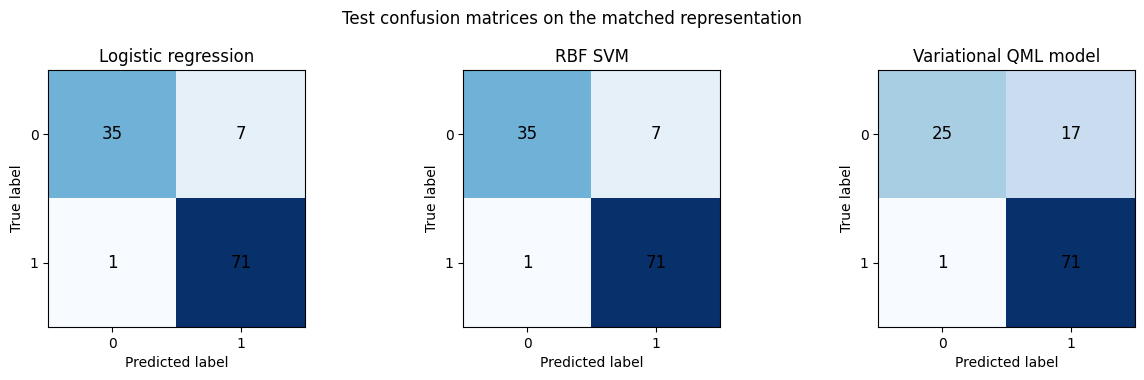

In [2]:
case_data = prepare_matched_breast_cancer(split_seed=11)
rows_case, trained_case = run_matched_models(case_data, quantum_seed=3)

print('Explained variance ratio of the two training-only PCA components:', np.round(case_data['explained_variance_ratio'], 4))
print_metric_table(rows_case)
plot_confusion_matrices(trained_case['test_confusions'], title='Test confusion matrices on the matched representation')


This output should be read as a matched-feature comparison, not as a universal ranking of all classical and quantum models on the original 30-dimensional task. The three models are being compared on the same two-dimensional representation, which is exactly the right protocol if the question is whether the variational model is competitive on the representation it actually uses.

The validation and test metrics also should not be collapsed into a single number. A model may look strong on validation yet lose that advantage on test, or it may keep similar accuracy while changing the confusion matrix in a clinically different way. That is why fair evaluation in QML requires both split hygiene and metric hygiene.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Fairness requires same split and same representation</b><br>
If the quantum model is trained on two PCA components, then the matched classical baselines should use those same two components in the comparison whose purpose is representation matching. If a classical baseline is allowed to use more features or a richer representation, that can still be informative, but it answers a broader problem-level question rather than the matched-representation question.
</div>


### Task 1 (coding): Strengthen the matched-baseline comparison

Using the same split seed `11` and the same train-only preprocessing pipeline of the example above, add two additional baselines on the matched two-feature representation: a <a href="https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html">DummyClassifier</a> with `strategy="most_frequent"` and a <a href="https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html">linear-kernel SVM</a>. Build one validation/test metric table containing all five models, then create a grouped bar chart of validation and test $F_1$ values for those five models after ordering them by validation $F_1$. Next, compute the test-$F_1$ gap between the variational QML model and each classical baseline. Use these results to decide whether the QML model beats only trivial baselines, also beats the linear matched baseline, or actually wins the full matched-feature comparison. Keep the comparison fully matched: same split, same transformed features, and no extra preprocessing fitted outside the training split.


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 1 solution:</b> <a href="04-evaluation-baselines-and-data-hygiene-solutions.ipynb#task1-solution">Click here for Task 1 solution</a>
</div>


In [3]:
# Task 1 starter
case_data_task1 = prepare_matched_breast_cancer(split_seed=11)

# TODO:
# 1. fit DummyClassifier(strategy="most_frequent") and SVC(kernel="linear", probability=True)
# 2. reuse run_matched_models(...) for the existing logistic, RBF SVM, and variational models
# 3. build one combined validation/test metric table for all five models
# 4. order the models by validation F1 and plot validation/test F1 side by side
# 5. compute the test-F1 gap between the variational model and every classical baseline
# 6. conclude whether the quantum model beats only trivial baselines, also the linear one, or wins overall


## Leakage through label-aware preprocessing

Some preprocessing steps are unsupervised, such as scaling or PCA. Others are label-aware, such as supervised feature selection. If a label-aware selector is fit on the full dataset before the split, then the training pipeline has already seen information from validation or test labels. That is direct leakage.

The next example isolates that issue with a simple logistic-regression pipeline. To make the effect easier to see, the training fraction is kept deliberately small. The clean protocol fits <a href="https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html">SelectKBest</a> on the training subset only. The leaked protocol fits the same selector on the full dataset before training. Both are then evaluated on the same held-out test set.


In [4]:
leak_example = selector_leakage_study(split_seed=19, k=2, train_fraction=0.18)
print('clean test accuracy :', round(leak_example['clean_test_accuracy'], 4))
print('leaked test accuracy:', round(leak_example['leaked_test_accuracy'], 4))
print('optimism gap        :', round(leak_example['optimism_gap'], 4))
print('clean features      :', leak_example['clean_features'])
print('leaked features     :', leak_example['leaked_features'])


clean test accuracy : 0.9165
leaked test accuracy: 0.9507
optimism gap        : 0.0343
clean features      : [np.str_('worst radius'), np.str_('worst perimeter')]
leaked features     : [np.str_('worst perimeter'), np.str_('worst concave points')]


The leaked protocol often looks slightly better because the feature selector has been allowed to use information that should have remained hidden at training time. The size of the optimism gap may vary from split to split, and in some runs it may even look numerically modest. That does not make the protocol acceptable. The problem is methodological: the final score is no longer an honest estimate of unseen-data performance.

This example is also a reminder that leakage does not require a dramatic coding mistake. A pipeline can look almost correct while still fitting a selector, scaler, threshold, or stopping rule in the wrong place. That is why fair QML evaluation must specify not only the model, but also the exact order in which preprocessing and split logic were applied.


<div style="background:#fff1d6;color:#111111;border-left:6px solid #d98500;padding:12px 14px;border-radius:6px;">
<b>Leakage can be numerically small and still invalidate the comparison</b><br>
If a leaked pipeline improves test accuracy by only one or two percentage points, the protocol is still broken. The issue is not the size of the gain; it is that the test estimate is no longer independent of training-time decisions.
</div>


### Task 2 (coding): Study how the optimism gap changes with the number of selected features

Repeat the selector-leakage study for split seeds `[3, 7, 11, 19, 27]`, but now use several values of the number of selected features, for example `k_values = [2, 4, 6, 8]`, with training fraction `0.18`. For every pair `(k, seed)`, record the clean test accuracy, the leaked test accuracy, and the optimism gap. Then build a single figure with two panels: one panel should compare the clean and leaked accuracies as functions of $k$ after averaging across seeds, and the other should summarize the distribution of optimism gaps across seeds for each $k$. Finally, identify which value of $k$ gives the largest mean optimism gap and explain what that figure says about why leakage can look persuasive even when the protocol is invalid.


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 2 solution:</b> <a href="04-evaluation-baselines-and-data-hygiene-solutions.ipynb#task2-solution">Click here for Task 2 solution</a>
</div>


In [5]:
# Task 2 starter
leakage_seeds = [3, 7, 11, 19, 27]
k_values_task2 = [2, 4, 6, 8]
train_fraction_task2 = 0.18

# TODO:
# 1. run selector_leakage_study(...) for every pair (k, seed)
# 2. store clean accuracy, leaked accuracy, and optimism gap in a list of rows
# 3. compute mean clean accuracy, mean leaked accuracy, and mean/max optimism gap for each k
# 4. build one figure with two panels: clean vs leaked accuracy by k, and gap distribution by k
# 5. identify which k gives the largest mean optimism gap
# 6. explain why the figure still does not legitimize the leaked protocol


## Repeated runs and reported uncertainty

A single split can be informative, but it is rarely enough for a strong empirical claim. If a chosen test metric $a_{\mathrm{test}}$ is recorded over repeated fair evaluations indexed by $k = 1, \dots, K$, then a basic summary is

$$
\bar a_{\mathrm{test}} = \frac{1}{K}\sum_{k=1}^{K} a_{\mathrm{test}}^{(k)},\qquad \sigma_{\mathrm{test}} = \sqrt{\frac{1}{K-1}\sum_{k=1}^{K}\bigl(a_{\mathrm{test}}^{(k)} - \bar a_{\mathrm{test}}\bigr)^2}
$$

The point is not to reduce evaluation to mean and standard deviation only. The point is to avoid treating one lucky split as if it were stable evidence. The next code cell repeats the matched-feature comparison over five split seeds and reports mean $\pm$ std for the validation and test metrics of all three core models.


Validation summary
model                              acc mean±std            F1 mean±std         ROC-AUC mean±std
-----------------------------------------------------------------------------------------------
Logistic regression             0.9368 ± 0.0144        0.9511 ± 0.0110          0.9918 ± 0.0038
RBF SVM                         0.9474 ± 0.0224        0.9586 ± 0.0170          0.9892 ± 0.0045
Variational QML model           0.8860 ± 0.0430        0.9169 ± 0.0290          0.9872 ± 0.0052

Test summary
model                              acc mean±std            F1 mean±std         ROC-AUC mean±std
-----------------------------------------------------------------------------------------------
Logistic regression             0.9439 ± 0.0147        0.9566 ± 0.0111          0.9891 ± 0.0072
RBF SVM                         0.9491 ± 0.0169        0.9599 ± 0.0137          0.9880 ± 0.0060
Variational QML model           0.8807 ± 0.0308        0.9130 ± 0.0202          0.9849 ± 0.0110


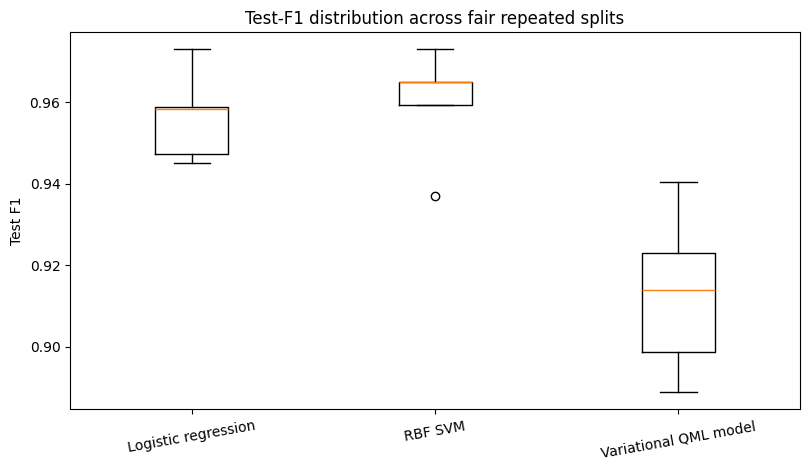

In [6]:
study_rows = repeated_matched_study(split_seeds=[2, 7, 13, 29, 41])
study_summary = summarize_repeated_results(study_rows)

print('Validation summary')
print_summary_table(study_summary, split_name='validation')
print('\nTest summary')
print_summary_table(study_summary, split_name='test')

models = ['Logistic regression', 'RBF SVM', 'Variational QML model']
fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.boxplot([[row['f1'] for row in study_rows if row['split'] == 'test' and row['model'] == model] for model in models], tick_labels=models)
ax.set_ylabel('Test F1')
ax.set_title('Test-F1 distribution across fair repeated splits')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


Repeated evaluation changes how the comparison should be read. Instead of asking only which model had the best score on one split, we can now ask how much each score fluctuates and whether the ranking is stable. A model that wins once but varies strongly across seeds may be less convincing than a slightly weaker model that behaves consistently.

This is also where claims about QML advantage should become more cautious, not less. If the quantum model is competitive only on one split or only under one favorable initialization, then the fair conclusion is not that it has clearly won. The fair conclusion is that the result is seed-sensitive and should be reported with that uncertainty visible.


### Task 3 (coding): How reliable is validation for ranking the models? 

Using the repeated fair comparison on split seeds `[2, 7, 13, 29, 41]`, compute the full ranking of the three core models by validation $F_1$ and by test $F_1$ for every seed. Then, for each model and each seed, compute the rank shift

$$
\Delta r_{\mathrm{model}}^{(k)} = r_{\mathrm{test}}^{(k)} - r_{\mathrm{val}}^{(k)}
$$

and the metric gap

$$
\Delta F_{1,\mathrm{model}}^{(k)} = F_{1,\mathrm{test}}^{(k)} - F_{1,\mathrm{val}}^{(k)}
$$

Build a single figure with two panels: one panel should show the rank shifts across seeds for all three models, and the other should summarize the distribution of $\Delta F_1$ values per model. Finally, report how often the validation winner is also the test winner, identify which model is the most stable under these two diagnostics, and explain why this is a stronger check than looking only at one winner count table.


<div style="background:#e8f1ff;color:#111111;border-left:6px solid #2f6fed;padding:12px 14px;border-radius:6px;">
<b>Task 3 solution:</b> <a href="04-evaluation-baselines-and-data-hygiene-solutions.ipynb#task3-solution">Click here for Task 3 solution</a>
</div>


In [7]:
# Task 3 starter
repeat_seeds_task3 = [2, 7, 13, 29, 41]

# TODO:
# 1. run repeated_matched_study(repeat_seeds_task3)
# 2. for each seed, build the full validation-F1 ranking and the full test-F1 ranking
# 3. compute rank shifts Delta r = r_test - r_val for every model and seed
# 4. compute Delta F1 = F1_test - F1_val for every model and seed
# 5. make one figure with two panels: rank shifts across seeds, and Delta-F1 distribution per model
# 6. count how often the validation winner is also the test winner
# 7. conclude which model looks most stable and why this goes beyond one winner table


## Brief note on regression metrics

The main case study above focuses on classification, but the same data-hygiene logic applies to regression. Using the same prediction notation $\hat y(\vec{x}^{\,j}, \boldsymbol{\theta})$, two standard per-sample losses are

$$
c_{\mathrm{MSE}}\bigl(y^j, \hat y(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)=\bigl(y^j - \hat y(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)^2
$$

$$
c_{\mathrm{MAE}}\bigl(y^j, \hat y(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)=\left|y^j - \hat y(\vec{x}^{\,j}, \boldsymbol{\theta})\right|
$$

Their empirical versions are

$$
\mathcal{L}_{\mathrm{MSE}}=\frac{1}{M}\sum_{j=1}^{M} c_{\mathrm{MSE}}\bigl(y^j, \hat y(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)
$$

$$
\mathcal{L}_{\mathrm{MAE}}=\frac{1}{M}\sum_{j=1}^{M} c_{\mathrm{MAE}}\bigl(y^j, \hat y(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)
$$

and a common goodness-of-fit score is the coefficient of determination,

$$
R^2=1 - \frac{\sum_{j=1}^{M}\bigl(y^j - \hat y(\vec{x}^{\,j}, \boldsymbol{\theta})\bigr)^2}{\sum_{j=1}^{M}\bigl(y^j - \bar y\bigr)^2}
$$

For regression tasks, one still needs train-validation-test separation, train-only preprocessing, repeated runs when relevant, and honest baseline models. Changing the metric does not remove the need for evaluation hygiene.

**Framework note.** For supervised regression, Qiskit Machine Learning provides <a href="https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.NeuralNetworkRegressor.html"><code>NeuralNetworkRegressor</code></a> and <a href="https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.VQR.html"><code>VQR</code></a>, which also expose scikit-learn-compatible <code>fit</code>, <code>predict</code>, and <code>score</code>. In that interface, <code>score</code> returns the regression coefficient of determination <code>R^2</code>. PennyLane again relies on the surrounding interface workflow or wrappers such as <a href="https://docs.pennylane.ai/en/stable/code/api/pennylane.qnn.TorchLayer.html"><code>qml.qnn.TorchLayer</code></a> rather than on a dedicated core regressor API.


## Key takeaways

- A fair QML evaluation starts with the split order: split first, fit preprocessing on training only, select on validation, and report once on test.
- Matched baselines should use the same transformed representation as the QML model if the question is representation matching.
- Leakage can be subtle; even small leaked gains invalidate the final comparison.
- Reporting one lucky split is not enough. Repeated fair runs reveal whether the ranking is stable or seed-sensitive.
- Strong empirical claims in QML require both competitive baselines and methodologically clean evaluation.
